# TP : Fouille de texte (FR) — Wordcloud, LDA, sentiment + bonus LLM (Mistral)

**Objectif :** produire des résultats **visuels** et **interprétables** sur un petit corpus français.

## Plan
1. Charger un corpus (CSV)
2. Nettoyage / lemmatisation simple (spaCy FR)
3. Nuage de mots (wordcloud)
4. Topics (LDA) et interprétation
5. (Optionnel) **LLM via API Mistral** : donner un titre aux topics + classer la tonalité

> ⚠️ Ce notebook fonctionne **sans LLM**. La partie Mistral est un bonus : elle nécessite une clé API (souvent avec quotas/gratuit selon votre compte).


## 0) Installation des dépendances
Exécuter cette cellule une seule fois.

In [1]:
#!pip -q install pandas numpy scikit-learn matplotlib wordcloud spacy requests
#!python -m spacy download fr_core_news_sm -q
#print("OK")

## 1) Charger le corpus

Le fichier exemple fourni avec ce TP : **corpus_fr_exemple.csv** (30 “brèves” de style média, **synthétiques**, pas de contenu sous copyright).

Colonnes : `date | source | titre | texte`


In [2]:
import pandas as pd

df = pd.read_csv("corpus_fr_exemple.csv")
df = df.dropna(subset=["texte"]).reset_index(drop=True)

print("Taille corpus:", len(df))
df.head(5)

Taille corpus: 30


,date,source,titre,texte
0,2026-02-18,Le Quotidien Local,Grève des trains : trafic perturbé dans plusie...,Une grève reconductible des conducteurs a rédu...
1,2026-02-20,InfoTech,L’IA générative s’invite dans les services pub...,Plusieurs administrations testent des assistan...
2,2026-02-21,ÉcoMatin,"Inflation : la hausse des prix ralentit, mais ...",Les derniers indicateurs montrent un ralentiss...
3,2026-02-22,Sport & Ville,Le club de la capitale se qualifie au bout du ...,"Dans un match très disputé, l’équipe s’est imp..."
4,2026-02-23,Planète,Sécheresse : des restrictions d’eau prolongées...,Plusieurs départements envisagent de prolonger...


## 2) Prétraitement (FR) : minuscule + lemmes + stopwords

On fait volontairement **simple** :
- on garde uniquement des mots alphabetiques
- on enlève les mots vides (stopwords)
- on garde les lemmes (forme “dictionnaire”)

> Pour un public non-tech, l’idée = “on enlève le bruit pour mieux voir les sujets”.


In [3]:
import re
import spacy

nlp = spacy.load("fr_core_news_sm")

def preprocess_fr(text: str) -> str:
    text = re.sub(r"\s+", " ", str(text))
    doc = nlp(text.lower())
    tokens = [
        t.lemma_
        for t in doc
        if t.is_alpha and not t.is_stop and len(t) > 2
    ]
    return " ".join(tokens)

df["texte_clean"] = df["texte"].map(preprocess_fr)
df[["titre","texte_clean"]].head(3)

,titre,texte_clean
0,Grève des trains : trafic perturbé dans plusie...,grève reconductible conducteur réduire circula...
1,L’IA générative s’invite dans les services pub...,administration tester assistant écriture résum...
2,"Inflation : la hausse des prix ralentit, mais ...",dernier indicateur montrer ralentissement infl...


## 3) Nuage de mots (Wordcloud)

À interpréter avec prudence :
- un mot fréquent n’est pas forcément un “sujet”
- les termes génériques peuvent dominer (ex : “annonce”, “mesure”, etc.)


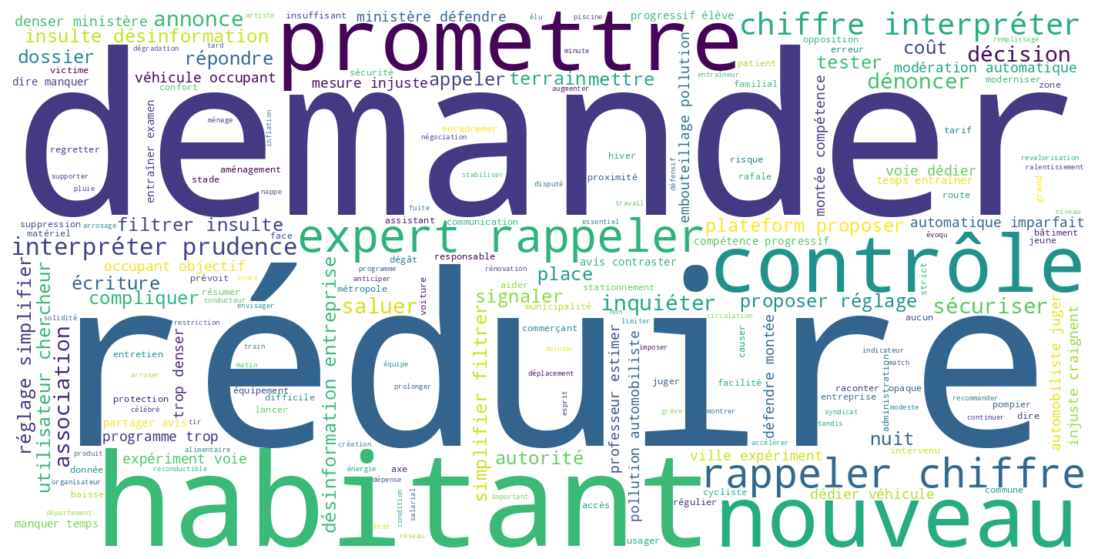

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df["texte_clean"].tolist())

wc = WordCloud(width=1400, height=700, background_color="white").generate(all_text)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

## 4) Topics avec LDA (très simple)

Idée : LDA “regroupe” les textes en **thèmes** (topics) à partir des co-occurrences de mots.  
Ici, on va :
- choisir `K=5` topics
- afficher les 10 mots principaux de chaque topic
- **interpréter** et **donner un titre** à chaque topic


In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_df=0.95, min_df=2)
X = vectorizer.fit_transform(df["texte_clean"])

K = 5
lda = LatentDirichletAllocation(n_components=K, random_state=0)
lda.fit(X)

vocab = vectorizer.get_feature_names_out()

def top_words(topic_weights, n=10):
    return [vocab[i] for i in topic_weights.argsort()[:-n-1:-1]]

topics = [top_words(lda.components_[k], 10) for k in range(K)]
for i, words in enumerate(topics, start=1):
    print(f"Topic {i}: {', '.join(words)}")

Topic 1: rappeler, contrôle, entreprise, promettre, réduire, juger, mesure, prudence, chiffre, expert
Topic 2: sécuriser, saluer, demander, nuit, habitant, annonce, signaler, place, voiture, axe
Topic 3: répondre, dossier, écriture, tester, hiver, face, décision, inquiéter, association, erreur
Topic 4: habitant, demander, coût, mettre, regretter, zone, proximité, sécurité, équipement, familial
Topic 5: nouveau, programme, élève, ministère, dire, trop, montée, temps, progressif, professeur


### 4.b) Assigner un “topic dominant” à chaque document

On ajoute deux colonnes :
- `topic_id` : topic dominant
- `topic_score` : score associé (plus grand = plus confiant)


In [6]:
import numpy as np

doc_topic = lda.transform(X)  # shape: (n_docs, K)

df["topic_id"] = doc_topic.argmax(axis=1) + 1
df["topic_score"] = doc_topic.max(axis=1)

df[["date","source","titre","topic_id","topic_score"]].head(10)

,date,source,titre,topic_id,topic_score
0,2026-02-18,Le Quotidien Local,Grève des trains : trafic perturbé dans plusie...,1,0.834986
1,2026-02-20,InfoTech,L’IA générative s’invite dans les services pub...,3,0.963590
2,2026-02-21,ÉcoMatin,"Inflation : la hausse des prix ralentit, mais ...",3,0.796707
3,2026-02-22,Sport & Ville,Le club de la capitale se qualifie au bout du ...,2,0.733317
4,2026-02-23,Planète,Sécheresse : des restrictions d’eau prolongées...,3,0.733093
5,2026-02-24,Culture Pop,Un festival mise sur la scène émergente et les...,5,0.910062
6,2026-02-25,Santé & Société,Vaccination : une campagne de rappel ciblée su...,3,0.885289
7,2026-02-26,Numérique,Fuite de données : une entreprise promet des m...,1,0.599972
8,2026-02-27,Éducation,Parcoursup : les lycéens demandent plus de tra...,3,0.684807
9,2026-02-28,Mobilités,Vélos en ville : le plan de pistes cyclables a...,2,0.961778


### 4.c) Petite lecture “média” : quels topics par source ?

On regarde la répartition des topics selon la colonne `source` (simule des “médias”).


In [7]:
import pandas as pd

pivot = pd.crosstab(df["source"], df["topic_id"], normalize="index").round(2)
pivot

topic_id,1,2,3,4,5
source,,,,,
Culture Pop,0.00,0.00,0.50,0.00,0.50
InfoTech,0.33,0.00,0.67,0.00,0.00
Le Quotidien Local,0.33,0.67,0.00,0.00,0.00
Mobilités,0.60,0.40,0.00,0.00,0.00
Numérique,1.00,0.00,0.00,0.00,0.00
Planète,0.00,0.50,0.50,0.00,0.00
Santé & Société,0.50,0.00,0.50,0.00,0.00
Sport & Ville,0.00,0.33,0.00,0.67,0.00
ÉcoMatin,0.00,0.00,1.00,0.00,0.00


### 5) Analyse de Polarité


In [14]:
from transformers import pipeline
import os

os.environ['HTTP_PROXY'] = 'http://cache.univ-st-etienne.fr:3128/'
os.environ['HTTPS_PROXY'] = 'http://cache.univ-st-etienne.fr:3128/'
sentiment = pipeline("sentiment-analysis", model="tabularisai/multilingual-sentiment-analysis")

def polarity_hf(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0, "neutre"
    out = sentiment(text[:512])[0]  # tronque pour éviter les textes trop longs
    # out: {'label': 'POSITIVE'/'NEGATIVE', 'score': 0.x}
    label = "positif" if out["label"].upper().startswith("POS") else "négatif"
    score = out["score"] if label == "positif" else -out["score"]
    return score, label

df[["polarity_score", "polarity_label"]] = df["texte_clean"].apply(
    lambda x: pd.Series(polarity_hf(x))
)

df[["titre", "polarity_score", "polarity_label"]].head(3)

C:\Users\ga102583\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ga102583\.cache\huggingface\hub\models--tabularisai--multilingual-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package i

,titre,polarity_score,polarity_label
0,Grève des trains : trafic perturbé dans plusie...,-0.379372,négatif
1,L’IA générative s’invite dans les services pub...,-0.935206,négatif
2,"Inflation : la hausse des prix ralentit, mais ...",-0.703804,négatif


## 6) Bonus : LLM via API **Mistral** (optionnel)

Objectifs pédagogiques :
- voir qu’un LLM peut servir de **stagiaire annotateur** (titres de topics, tonalité, résumé…)
- comprendre les limites (coût, quotas, biais, hallucinations)

### Prérequis
1. Créer une clé API Mistral (AI Studio / plateforme Mistral)
2. Dans Colab : **Paramètres / Secrets** (ou variables d’environnement) → ajouter `MISTRAL_API_KEY`
3. Relancer le runtime si besoin.

Docs officielles : endpoint “chat” et quickstart Mistral. (Voir docs.mistral.ai)


In [15]:
import os, requests, json, time

MISTRAL_API_KEY = "caowyfxmdKEXyW8EN2Y9LtvtcdCw1hvh"
if not MISTRAL_API_KEY:
    print("⚠️ Pas de clé Mistral trouvée. Ajoute MISTRAL_API_KEY dans les secrets Colab pour activer le bonus.")
else:
    print("✅ Clé Mistral détectée (bonus activable).")

✅ Clé Mistral détectée (bonus activable).


### 6.a) Fonction utilitaire : appeler Mistral Chat Completions

On utilise l’endpoint standard : `https://api.mistral.ai/v1/chat/completions`.

> Astuce cours : limiter la taille des entrées, et ne pas appeler le LLM sur 200 textes d’un coup.


In [16]:
def mistral_chat(messages, model="mistral-small-latest", max_tokens=150, temperature=0.2):
    if not MISTRAL_API_KEY:
        raise RuntimeError("MISTRAL_API_KEY manquante.")
    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {MISTRAL_API_KEY}", "Content-Type": "application/json"}
    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
    }
    r = requests.post(url, headers=headers, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    return data["choices"][0]["message"]["content"].strip()

# Test rapide (décommente si clé présente)
# print(mistral_chat([{"role":"user","content":"Donne 3 synonymes de 'rapide' en français."}]))

### 6.b) Faire titrer automatiquement les topics LDA

On fournit au LLM :
- la liste des mots du topic
- une consigne de titre court

Le LLM renvoie un libellé lisible (“Mobilités urbaines”, “Santé publique”, etc.)


In [17]:
def label_topic(words):
    prompt = (
        "Tu es analyste médias. Donne un titre court (3 à 6 mots) "
        "pour un thème représenté par ces mots :\n"
        f"{', '.join(words)}\n\n"
        "Réponds uniquement par le titre."
    )
    return mistral_chat([{"role":"user","content": prompt}], max_tokens=30, temperature=0.1)

topic_labels = []
if MISTRAL_API_KEY:
    for words in topics:
        topic_labels.append(label_topic(words))
        time.sleep(0.5)  # petit délai pour éviter des limites de débit
    for i, (lab, words) in enumerate(zip(topic_labels, topics), start=1):
        print(f"Topic {i} → {lab} | mots: {', '.join(words)}")
else:
    print("Clé absente → saute cette cellule.")

Topic 1 → "Contrôle prudent des chiffres" | mots: rappeler, contrôle, entreprise, promettre, réduire, juger, mesure, prudence, chiffre, expert
Topic 2 → "Sécurité nocturne en ville" | mots: sécuriser, saluer, demander, nuit, habitant, annonce, signaler, place, voiture, axe
Topic 3 → "Décisions hivernales sous pression" | mots: répondre, dossier, écriture, tester, hiver, face, décision, inquiéter, association, erreur
Topic 4 → "Proximité et sécurité des équipements familiaux" | mots: habitant, demander, coût, mettre, regretter, zone, proximité, sécurité, équipement, familial
Topic 5 → "Nouveau programme trop progressif" | mots: nouveau, programme, élève, ministère, dire, trop, montée, temps, progressif, professeur


### 6.c) Classer la “tonalité” de titres (positif / négatif / neutre)

Ici on fait très simple :
- on envoie uniquement le **titre** (court)
- on demande une sortie **JSON** pour pouvoir compter facilement

> Important : ce n’est pas “la vérité”. C’est une estimation, sensible au prompt, au modèle, au contexte.


In [23]:
import json

def sentiment_title(title):
    prompt = f'''
Classe la tonalité de ce titre de presse en français :
"{title}"

Réponds en JSON strict, sans texte autour, avec les clés:
- label: "positif" | "negatif" | "neutre"
- justification: une phrase courte
'''.strip()
    out = mistral_chat([{"role":"user","content": prompt}], max_tokens=120, temperature=0.0)
    return json.loads("\n".join(out.split("\n")[1:-1]))

if MISTRAL_API_KEY:
    sample = df["titre"].head(8).tolist()
    results = [sentiment_title(t) for t in sample]
    for t, r in zip(sample, results):
        print("-", t)
        print(" ", r["label"], "|", r["justification"])
else:
    print("Clé absente → saute cette cellule.")

Classe la tonalité de ce titre de presse en français :
"Grève des trains : trafic perturbé dans plusieurs régions"

Réponds en JSON strict, sans texte autour, avec les clés:
- label: "positif" | "negatif" | "neutre"
- justification: une phrase courte
```json
{
  "label": "negatif",
  "justification": "Le titre évoque des perturbations, ce qui est généralement perçu comme une situation défavorable."
}
```
Classe la tonalité de ce titre de presse en français :
"L’IA générative s’invite dans les services publics"

Réponds en JSON strict, sans texte autour, avec les clés:
- label: "positif" | "negatif" | "neutre"
- justification: une phrase courte
```json
{
  "label": "neutre",
  "justification": "Le titre est informatif sans connotation positive ou négative."
}
```
Classe la tonalité de ce titre de presse en français :
"Inflation : la hausse des prix ralentit, mais l’alimentation reste chère"

Réponds en JSON strict, sans texte autour, avec les clés:
- label: "positif" | "negatif" | "neut

### 6.d) (Mini-atelier) : annoter 20 titres, puis faire un petit bilan

On prend un sous-échantillon pour rester gratuit/rapide.


In [ ]:
from collections import Counter

if MISTRAL_API_KEY:
    sub = df.sample(20, random_state=0).copy()
    labels = []
    for t in sub["titre"].tolist():
        try:
            r = sentiment_title(t)
            labels.append(r["label"])
            time.sleep(0.4)
        except Exception as e:
            labels.append("erreur")
            print("Erreur sur:", t, "|", e)

    sub["sentiment_llm"] = labels
    display(sub[["date","source","titre","sentiment_llm"]].head(10))

    print("Bilan:", Counter(labels))
else:
    print("Clé absente → saute cette cellule.")

Classe la tonalité de ce titre de presse en français :
"Inflation : la hausse des prix ralentit, mais l’alimentation reste chère"

Réponds en JSON strict, sans texte autour, avec les clés:
- label: "positif" | "negatif" | "neutre"
- justification: une phrase courte
```json
{
  "label": "neutre",
  "justification": "Le titre mentionne une amélioration partielle (ralentissement de l'inflation) mais souligne un problème persistant (prix élevés de l'alimentation)."
}
```
Classe la tonalité de ce titre de presse en français :
"Covoiturage : une voie réservée testée sur le périphérique"

Réponds en JSON strict, sans texte autour, avec les clés:
- label: "positif" | "negatif" | "neutre"
- justification: une phrase courte
```json
{
  "label": "neutre",
  "justification": "Le titre présente une information factuelle sans jugement de valeur."
}
```
Classe la tonalité de ce titre de presse en français :
"Hôpitaux : les urgences sous tension le week-end"

Réponds en JSON strict, sans texte autour,

## 7) Questions d’interprétation

1. Quels mots dominent le nuage de mots ? Qu’est-ce que ça “rate” ?  
2. Propose un titre humain pour chaque topic LDA (même si tu as utilisé le LLM).  
3. Compare deux `source` : ont-elles les mêmes thèmes dominants ?  
4. Si tu as utilisé le LLM : as-tu vu des erreurs / biais ? Donne 2 exemples.
